#### **Generator & Evaluator**

In [71]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()

if os.environ.get("OPENAI_API_KEY") is None:
    raise ValueError("OpenAI API Key is not found.")
else:
    print("OpenAI API key is set.")

llm_model = ChatOpenAI(model="gpt-4-0613", temperature=0.7)
llm_model.invoke('When did india got freedom')

OpenAI API key is set.


AIMessage(content='India got its independence from British rule on August 15, 1947.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 12, 'total_tokens': 28, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-DHUY1XzCgO7qeG8KyQfTw1w9YDArB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd2b1-740f-7570-8eb0-a5d0cece00b6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 16, 'total_tokens': 28, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

#### **LLM Schema & Graph Schema**

In [72]:
from typing import TypedDict, Literal, List
from pydantic import Field

class llm_schema(TypedDict):
    feedback_flag: Literal ['funny', 'not funny']= Field(description='This is the flag which check if the jock is funny or not funny')
    feedback: str=Field(description='Feedback on the Jock.')

class graph_schema(TypedDict):
    topic: str
    jock: str
    feedback: str
    feedback_flag: str
    max_iteration: int

llm_with_schema=llm_model.with_structured_output(llm_schema)


#### **Create Nodes**

In [73]:
def generator_node(state:graph_schema):
    feedback = state['feedback']
    jock = state['jock']
    topic = state['topic']
    if feedback:
        response = llm_model.invoke(f'Please evaluate modify the {jock}: Based on the given Feedback: {feedback}')
    else:
        response = llm_model.invoke(f'Please make one jock on the given topic {topic}')
    state['jock'] = response.content

    return state

In [74]:
from langchain_core.prompts import ChatPromptTemplate
def evaluator_node(state:graph_schema):
    jock = state['jock']
    iterator = state['max_iteration']

    prompt = ChatPromptTemplate([
        
            ('system','You are a Comedian, your job is to make the jock funnier'),
            ('human',f'please give a jock {jock} and Evaluate the intensity of Jock by rating it either funny or not funny also give a feedback if it is not funny')
    ])

    chain = prompt | llm_with_schema
    response = chain.invoke({'jock':jock})
    state['feedback_flag'] = response['feedback_flag']
    state['feedback'] = response['feedback']
    state['max_iteration']= iterator + 1
    return state


#### **Check for Condition**

In [75]:
def if_condition(state:graph_schema):
    if state['feedback_flag']!= 'funny' and state['max_iteration']<=5:
        return 'evaluator_node'
    else:
        return 'end'


#### **State Graph**

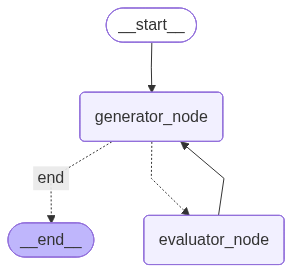

In [76]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# add node
graph.add_node('generator_node', generator_node)
graph.add_node('evaluator_node', evaluator_node)

# add edge
graph.add_edge(START, 'generator_node')
graph.add_conditional_edges('generator_node', if_condition, {'evaluator_node':'evaluator_node', 'end':END})
graph.add_edge('evaluator_node', 'generator_node')
graph.add_edge('generator_node', END)

final_graph = graph.compile()

from IPython.display import Image
Image(final_graph.get_graph().draw_mermaid_png())


#### **Invoke Graph and Test WorkFlow**

In [77]:
for chunk in final_graph.stream(
    {
        'topic':'Women',
        "feedback":"",
        'feedback_flag':"",
        'jock':"",
        'max_iteration':0
    },
    stream_mode='updates'
):

    print('chunk-->',chunk)

chunk--> {'generator_node': {'topic': 'Women', 'jock': "Why don't women need a watch?\n\nBecause there's always a clock in the kitchen!", 'feedback': '', 'feedback_flag': '', 'max_iteration': 0}}
chunk--> {'evaluator_node': {'topic': 'Women', 'jock': "Why don't women need a watch?\n\nBecause there's always a clock in the kitchen!", 'feedback': "This joke has a stereotypical punchline which can be seen as humorous to some. However, it's important to note that humor can be subjective and this joke might not be appreciated by everyone due to its gender-based stereotype.", 'feedback_flag': 'funny', 'max_iteration': 1}}
chunk--> {'generator_node': {'topic': 'Women', 'jock': "Why don't soccer players need a watch?\n\nBecause there's always a clock on the field!", 'feedback': "This joke has a stereotypical punchline which can be seen as humorous to some. However, it's important to note that humor can be subjective and this joke might not be appreciated by everyone due to its gender-based ster